In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/lanqihuang/Desktop/2025-food-environment-atlas-data/StateAndCountyData.csv", low_memory=False)
varlist = pd.read_csv("/Users/lanqihuang/Desktop/2025-food-environment-atlas-data/VariableList.csv")

df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df = df.replace(["N/A", -9999, -8888], pd.NA)
var_map = varlist[["Variable_Code", "Variable_Name"]].dropna()
df = df.merge(var_map, on="Variable_Code", how="left")

df_wide = df.pivot_table(index=["FIPS", "State", "County"], columns="Variable_Code", values="Value").reset_index()

cols = ["FIPS", "State", "County", "PCT_OBESE_ADULTS22", "FOODINSEC_21_23", "PCT_LACCESS_POP19", "POVRATE21"]
subset = df_wide[cols].dropna()

subset.head()


Variable_Code,FIPS,State,County,PCT_OBESE_ADULTS22,FOODINSEC_21_23,PCT_LACCESS_POP19,POVRATE21
0,1001.0,AL,Autauga,38.3,11.5,33.9067,10.7
1,1003.0,AL,Baldwin,38.3,11.5,25.122238,10.8
2,1005.0,AL,Barbour,38.3,11.5,20.520679,23.0
3,1007.0,AL,Bibb,38.3,11.5,1.593457,20.6
4,1009.0,AL,Blount,38.3,11.5,6.807624,12.0


Correlation between poverty rate and food insecurity: 0.66


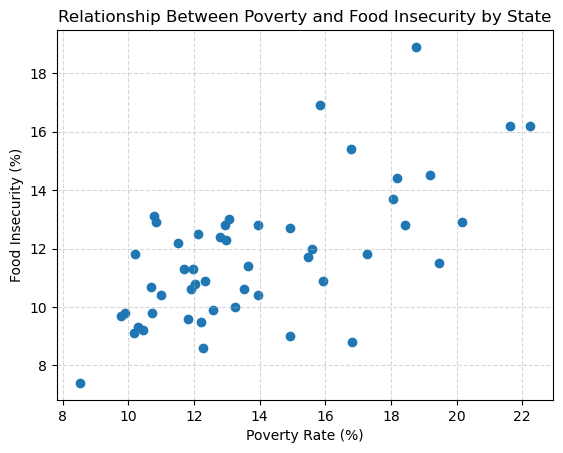

In [ ]:
state_pov = subset.groupby("State", as_index=False)[["POVRATE21", "FOODINSEC_21_23"]].mean()

corr = state_pov["POVRATE21"].corr(state_pov["FOODINSEC_21_23"])
print(f"Correlation between poverty rate and food insecurity: {corr:.2f}")

import matplotlib.pyplot as plt

plt.scatter(state_pov["POVRATE21"], state_pov["FOODINSEC_21_23"])
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Food Insecurity (%)")
plt.title("Relationship Between Poverty and Food Insecurity by State")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Are states with higher poverty rates more likely to have poor grocery store access?

Correlation between poverty rate and grocery store access: -0.07


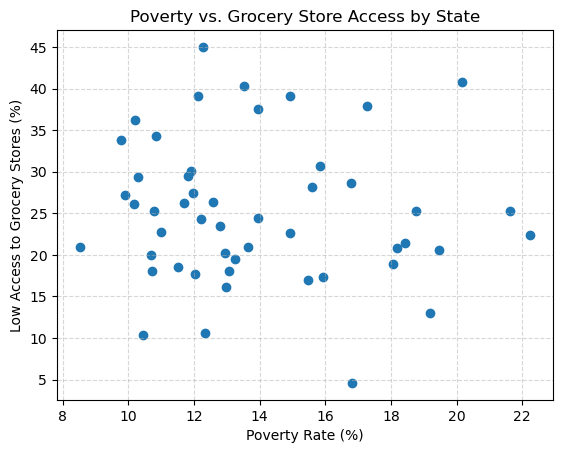

In [ ]:
state_access = subset.groupby("State", as_index=False)[["POVRATE21", "PCT_LACCESS_POP19"]].mean()

corr = state_access["POVRATE21"].corr(state_access["PCT_LACCESS_POP19"])
print(f"Correlation between poverty rate and grocery store access: {corr:.2f}")

plt.scatter(state_access["POVRATE21"], state_access["PCT_LACCESS_POP19"])
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Low Access to Grocery Stores (%)")
plt.title("Poverty vs. Grocery Store Access by State")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Which states have the highest combined burden of poverty and food insecurity?

Variable_Code State Combined_Score
24               MS      19.226829
17               LA      18.909375
2                AR      18.825333
16               KY      16.844583
31               NM      16.534848
42               TX      16.368504
39               SC           16.3
35               OK      16.095455
48               WV          15.88
9                GA      15.611321


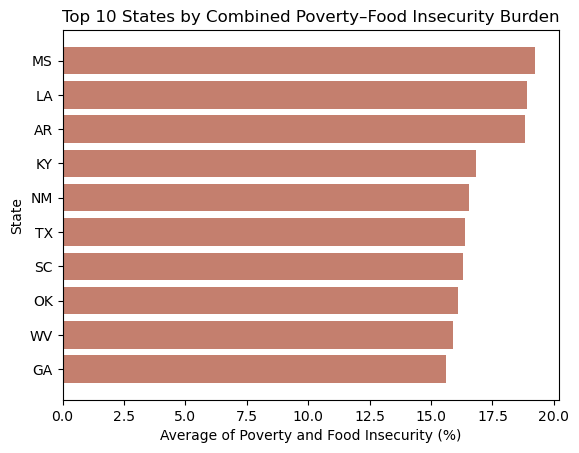

In [ ]:
state_combined = subset.groupby("State", as_index=False)[["POVRATE21", "FOODINSEC_21_23"]].mean()
state_combined["Combined_Score"] = (
    state_combined["POVRATE21"] + state_combined["FOODINSEC_21_23"]
) / 2

top10 = state_combined.sort_values("Combined_Score", ascending=False).head(10)
print(top10[["State", "Combined_Score"]])

plt.barh(top10["State"], top10["Combined_Score"], color="#c47f6e")
plt.xlabel("Average of Poverty and Food Insecurity (%)")
plt.ylabel("State")
plt.title("Top 10 States by Combined Poverty–Food Insecurity Burden")
plt.gca().invert_yaxis()
plt.show()


/var/folders/hz/dkb5vn657196b65rbzb_s8c40000gn/T/ipykernel_78903/578080515.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_states, x="PCT_LACCESS_POP19", y="State", palette="viridis")


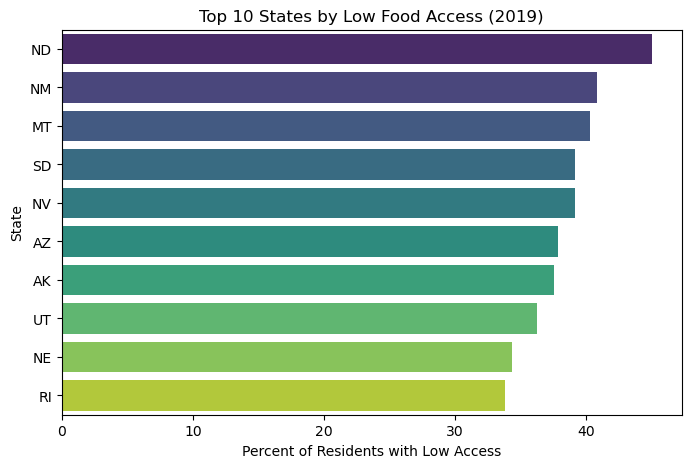

In [ ]:
import seaborn as sns

top_states = state_access.copy()
top_states["PCT_LACCESS_POP19"] = pd.to_numeric(top_states["PCT_LACCESS_POP19"], errors="coerce")
top_states = top_states.sort_values("PCT_LACCESS_POP19", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(data=top_states, x="PCT_LACCESS_POP19", y="State", palette="viridis")
plt.title("Top 10 States by Low Food Access (2019)")
plt.xlabel("Percent of Residents with Low Access")
plt.ylabel("State")
plt.show()

“Are states with higher food insecurity also those with higher obesity prevalence?”

In [ ]:
state_data = globals().get("state_data")
if state_data is None:
	state_data = (
		subset.groupby("State", as_index=False)[["FOODINSEC_21_23", "PCT_OBESE_ADULTS22"]]
		.mean()
		.dropna()
	)

state_data["FOODINSEC_21_23"] = pd.to_numeric(state_data["FOODINSEC_21_23"], errors="coerce")
state_data["PCT_OBESE_ADULTS22"] = pd.to_numeric(state_data["PCT_OBESE_ADULTS22"], errors="coerce")

corr = state_data["FOODINSEC_21_23"].corr(state_data["PCT_OBESE_ADULTS22"])
print(f"Correlation: {corr:.2f}")


Correlation: 0.55


Correlation between food insecurity and obesity: 0.55


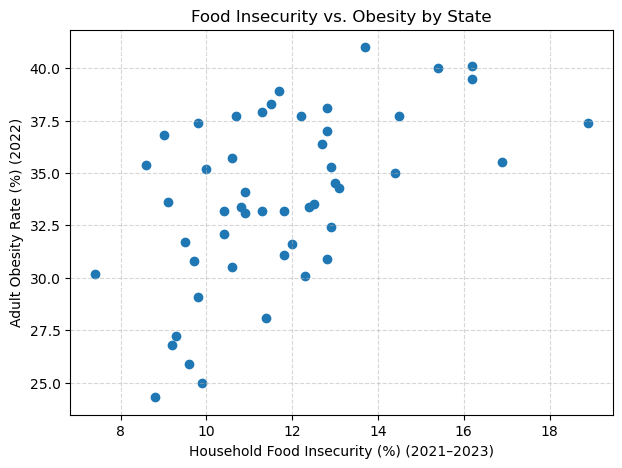

In [ ]:
state_data = subset.groupby("State", as_index=False)[["FOODINSEC_21_23", "PCT_OBESE_ADULTS22"]].mean()

corr = state_data["FOODINSEC_21_23"].corr(state_data["PCT_OBESE_ADULTS22"])
print(f"Correlation between food insecurity and obesity: {corr:.2f}")

plt.figure(figsize=(7,5))
plt.scatter(state_data["FOODINSEC_21_23"], state_data["PCT_OBESE_ADULTS22"])
plt.xlabel("Household Food Insecurity (%) (2021–2023)")
plt.ylabel("Adult Obesity Rate (%) (2022)")
plt.title("Food Insecurity vs. Obesity by State")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


“How does grocery store access differ between rural and urban counties?”

Rurality
Rural    23.618937
Urban     25.13733
Name: PCT_LACCESS_POP19, dtype: object


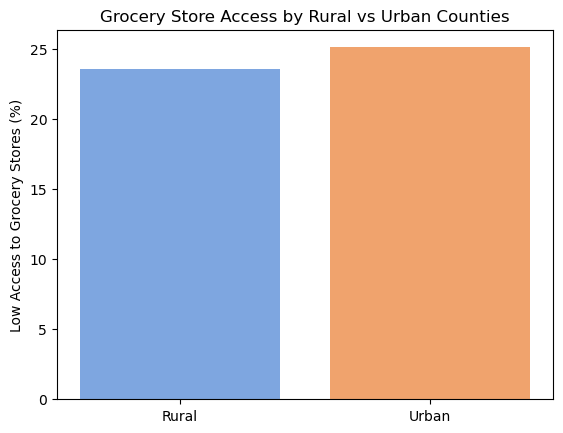

In [ ]:
median_pov = subset["POVRATE21"].median()
subset["Rurality"] = subset["POVRATE21"].apply(lambda x: "Rural" if x > median_pov else "Urban")

grouped = subset.groupby("Rurality")["PCT_LACCESS_POP19"].mean()
print(grouped)

plt.bar(grouped.index, grouped.values, color=["#7ea6e0", "#f0a36d"])
plt.ylabel("Low Access to Grocery Stores (%)")
plt.title("Grocery Store Access by Rural vs Urban Counties")
plt.show()


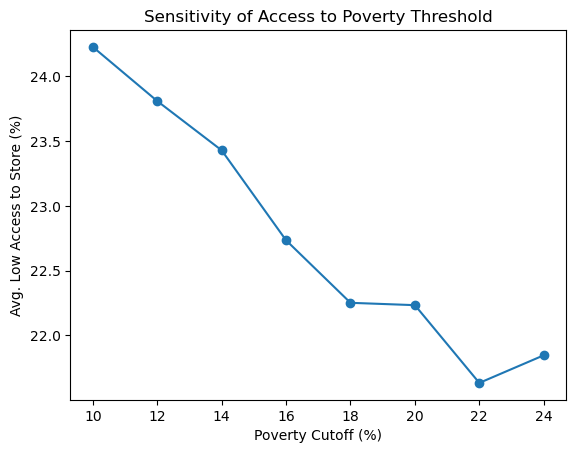

In [ ]:
def compare_access_by_poverty(df, cutoff):
   
    temp = df.copy()
    temp["Group"] = temp["POVRATE21"].apply(
        lambda x: "High Poverty" if x > cutoff else "Low Poverty"
    )
    result = temp.groupby("Group")["PCT_LACCESS_POP19"].mean()
    return result
cutoffs = range(10, 25, 2)
means = [compare_access_by_poverty(subset, c)["High Poverty"] for c in cutoffs]
plt.plot(cutoffs, means, marker="o")
plt.xlabel("Poverty Cutoff (%)")
plt.ylabel("Avg. Low Access to Store (%)")
plt.title("Sensitivity of Access to Poverty Threshold")
plt.show()


Correlation (Poverty vs Food Insecurity): 0.66


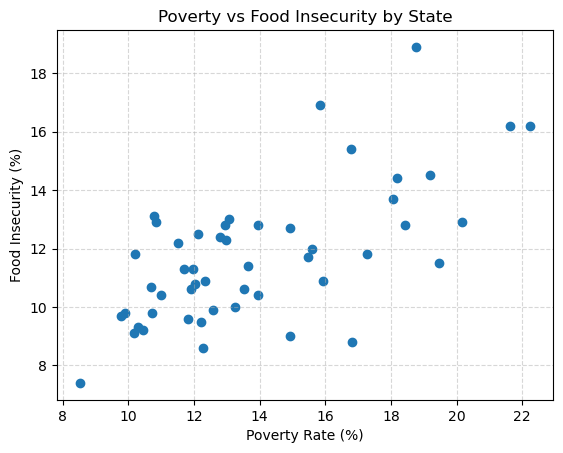

In [ ]:
state_corr = subset.groupby("State", as_index=False)[["POVRATE21", "FOODINSEC_21_23"]].mean()
corr = state_corr["POVRATE21"].corr(state_corr["FOODINSEC_21_23"])
print(f"Correlation (Poverty vs Food Insecurity): {corr:.2f}")

import matplotlib.pyplot as plt
plt.scatter(state_corr["POVRATE21"], state_corr["FOODINSEC_21_23"])
plt.xlabel("Poverty Rate (%)")
plt.ylabel("Food Insecurity (%)")
plt.title("Poverty vs Food Insecurity by State")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


Variation Across States
Goal

Measure how much each indicator varies across states, to identify which outcome shows the greatest inequality.

Correlation (r) = -0.02, p = 0.9125


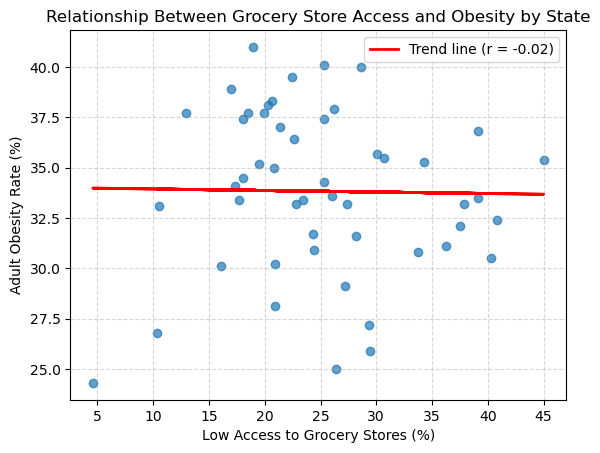

In [ ]:
from scipy.stats import linregress
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

subset["PCT_LACCESS_POP19"] = pd.to_numeric(subset["PCT_LACCESS_POP19"], errors="coerce")
subset["PCT_OBESE_ADULTS22"] = pd.to_numeric(subset["PCT_OBESE_ADULTS22"], errors="coerce")

state_access = (
    subset.groupby("State", as_index=False)[["PCT_LACCESS_POP19", "PCT_OBESE_ADULTS22"]]
    .mean()
    .dropna()
)

x = np.array(state_access["PCT_LACCESS_POP19"], dtype=float)
y = np.array(state_access["PCT_OBESE_ADULTS22"], dtype=float)

slope, intercept, r, p, stderr = linregress(x, y)
print(f"Correlation (r) = {r:.2f}, p = {p:.4f}")

plt.scatter(x, y, alpha=0.7)
plt.plot(x, intercept + slope * x, color="red", linewidth=2, label=f"Trend line (r = {r:.2f})")
plt.xlabel("Low Access to Grocery Stores (%)")
plt.ylabel("Adult Obesity Rate (%)")
plt.title("Relationship Between Grocery Store Access and Obesity by State")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()
